# FEM Pendulum: Torque Application

In this second tutorial on the FEM implementation of the pendulum, we extend the basic model by applying an external torque at the pivot point.

1. **[Basics](01_fem_pendulum_basics.ipynb)**: We set up the basic model of a deformable pendulum without contact and external torque.
2. **Torque Application** (this tutorial): We extend the basic model by applying an external torque at the pivot point.
3. **[Contact Handling](03_fem_pendulum_contact.ipynb)**: We further extend the model by adding contact handling with a wall.

Following references were used to implement the model:
- [Nonlinear Elasticity - NGSolve 24](https://docu.ngsolve.org/ngs24/SaS/nonlinearelasticity.html)
- [Elastic Pendulum - NGS Tutorial 2024](https://docu.ngsolve.org/ngs24/tutorials/00_dynamics.html)
- [Contact Problems - NGS Docu Interactive Tutorial](https://docu.ngsolve.org/latest/i-tutorials/unit-6.2-contact/contact.html)
- [An Interactive Introduction to the Finite Element Method, Joachim Schöberl, TU Wien, ASC](https://jschoeberl.github.io/iFEM/intro.html)

:::{figure} /_static/fem_pendulum_torque.gif
:alt: FEM pendulum torque application
:width: 600px

Torque applied to FEM without gravitational effects.
:::

## Overview

This tutorial adds a **torque input** to the deformable 2D pendulum from Tutorial 01.

Core ideas:
1) Represent a desired actuator torque $M_z^{\mathrm{drive}}(t)$ as a **distributed boundary traction** on the hinge edge `rotation`.
2) Choose a **signed traction weight** $w(s)$ that yields *zero net force* but a non-zero moment (pure torque).
3) Implement the traction as a **follower load** (always normal to the *current* hinge edge).
4) Verify the implementation by applying a constant torque with gravity **off** and **on** and comparing the observed motion.

## Learning Goals

- Extend the weak form of nonlinear elastodynamics by a torque-like actuation term.
- Understand how a *pure torque* can be generated by a *zero-resultant traction distribution*.
- Implement and motivate a **follower traction** (normal follows the deformed hinge edge).
- Visualize and sanity-check the applied torque with and without gravity.

## Prerequisites and Setup

This notebook assumes you understand the basic setup from [FEM Pendulum: Basics](01_fem_pendulum_basics.ipynb):

- 2D planar pendulum with out-of-plane thickness $h$
- hyperelastic (Neo-Hookean) material law
- hinge modeled by a mean-zero displacement constraint on the top edge `rotation`

Notes:
- All quantities are SI.
- We do **not** include damping or wall contact here (that is Tutorial 03).
- In the documentation build, notebooks are not executed (`nb_execution_mode = off`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from netgen.occ import *
from ngsolve import *
from ngsolve.solvers import NewtonMinimization
from ngsolve.webgui import Draw

## Physical Model and Governing Equations (with torque)

We solve **nonlinear elastodynamics** for the displacement field $u(X,t)$ on the reference domain $\Omega_0 \subset \mathbb{R}^2$.

### Rigid-body intuition

For a perfectly rigid pendulum with angle $\theta(t)$, inertia $I$ about the pivot, and center-of-mass distance $\ell$, the equation of motion is

$$
I\,\ddot{\theta}(t) = M_z^{\mathrm{drive}}(t) - M_z^{\mathrm{grav}}(\theta),
\qquad
M_z^{\mathrm{grav}}(\theta) = m g \ell \sin\theta.
$$

This tutorial shows how to realize the input torque $M_z^{\mathrm{drive}}$ in a continuum FEM model.

### Continuum elastodynamics (reference configuration)

A standard Lagrangian form is

$$
\rho_0\,\ddot{u} = \nabla_0 \cdot P(F) + \rho_0 b \quad \text{in } \Omega_0,\qquad
F = I + \nabla_0 u.
$$

- $\rho_0 = \rho\,h$ is the (area) density of the 2D model with thickness $h$.
- $P(F) = \partial W(F)/\partial F$ is the first Piola–Kirchhoff stress of the hyperelastic material.
- $b=(0,-g)$ is the body acceleration (gravity).

### Hinge (pivot) constraint

The top edge $\Gamma_{\mathrm{rot}}$ is not clamped pointwise. Instead we prevent translation of that edge by enforcing the **mean-zero displacement**

$$
\int_{\Gamma_{\mathrm{rot}}} u\, ds = 0,
$$

implemented with two Lagrange multipliers (one for $x$, one for $y$). For a symmetric hinge edge whose midpoint is at the origin, this keeps the pivot fixed while allowing rotation.

## From a normal traction to a pure torque

Let $r$ be the position vector relative to the pivot. The out-of-plane moment generated by a traction $t$ acting on the hinge edge $\Gamma_{\mathrm{rot}}$ is

$$
M_z = \int_{\Gamma_{\mathrm{rot}}} (r \times t)_z\, ds
    = \int_{\Gamma_{\mathrm{rot}}} (r_x\,t_y - r_y\,t_x)\, ds.
$$

We choose a **normal traction** with a signed weight $w(s)$ along the edge:

$$
 t(s) = p_0\, w(s)\, n(s),
$$

where $n(s)$ is the outward unit normal and $p_0$ is a scalar amplitude.

### Zero net force (pure torque)

The resultant force is

$$
F = \int_{\Gamma_{\mathrm{rot}}} t\,ds = p_0\,\int_{\Gamma_{\mathrm{rot}}} w(s)\,n(s)\,ds.
$$

For a straight hinge edge with (approximately) constant normal $n$, it is sufficient to enforce a **zero-mean weight**

$$
\int_{\Gamma_{\mathrm{rot}}} w(s)\, ds = 0.
$$

### Torque-to-traction conversion

With the choice above,

$$
M_z = p_0\,\underbrace{\int_{\Gamma_{\mathrm{rot}}} w(s)\,(r \times n)_z\, ds}_{D_{\mathrm{eff}}}.
$$

The factor $D_{\mathrm{eff}}$ is a purely geometric effectiveness (an “effective lever arm”) for the chosen $w$. We therefore set

$$
 p_0 = \frac{M_z^{\mathrm{drive}}}{D_{\mathrm{eff}}}.
$$

## Basic Implementation

We first mirror the setup from Tutorial 01, then add the torque application.

### Geometry and mesh

We reuse the same pendulum geometry as in Tutorial 01. The top edge is named `rotation`; its midpoint is the pivot point $(0,0)$.

In [3]:
# Geometry parameters
r_rod = 0.015   # rod radius in meters
r_hole = 0.03   # hole radius in meters
r_head = 0.06   # head radius in meters
l_center = 0.24 # length to center of head in meters

bar = MoveTo(-r_rod, 0).Rectangle(2 * r_rod, l_center).Face()
bar.edges.Min(Y).name = "rotation"
bar.edges.Min(Y).maxh = r_rod / 10
bar.faces.name = "bar"
bar.faces.maxh = r_rod / 2

hole = Circle((0, l_center), r_hole).Face()
hole.faces.name = "hole"
hole.edges.maxh = r_head / 20

circ = Circle((0, l_center), r_head).Face()
circ.edges.maxh = r_head / 20
circ.faces.name = "circ"
circ.faces.maxh = r_head / 5

head = circ - hole
pendulum = head + bar - hole

# Rotate so the pendulum initially points downward
pendulum = pendulum.Rotate(Axis((0.0, 0, 0), (0, 0, 1)), 180)
pendulum.name = "pendulum"

geo = OCCGeometry(pendulum, dim=2)

max_element_size = 0.03
mesh_order = 2

mesh = Mesh(geo.GenerateMesh(maxh=max_element_size))
mesh.Curve(mesh_order)

Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

### Material model (Neo-Hookean, plane stress)

We reuse the compressible Neo-Hookean energy density from Tutorial 01 with the **plane-stress** first Lamé parameter $\lambda^{*} = E\nu/(1-\nu^{2})$, since the pendulum is modeled as a thin plate. The 2D reduction is kept for **reduced computational cost**.

In [4]:
E = 2.1e11    # Young's modulus [Pa]
nu = 0.3      # Poisson ratio
rho = 7800    # Mass density [kg/m^3]
thickness = 0.01  # Thin plate (plane-stress assumption) [m]

# Useful reference quantities for verification
rhoA = rho * thickness

r = CF((x-0, y-0))
fem_mass = Integrate(rhoA, mesh, definedon=mesh.Materials("pendulum"))
fem_inertia = Integrate(rhoA * InnerProduct(r, r), mesh, definedon=mesh.Materials("pendulum"))

cx = Integrate(rhoA * x, mesh, definedon=mesh.Materials("pendulum")) / fem_mass
cy = Integrate(rhoA * y, mesh, definedon=mesh.Materials("pendulum")) / fem_mass
fem_l_com = np.sqrt(cx**2 + cy**2)

print(f"mass    = {fem_mass:.6f} kg")
print(f"inertia = {fem_inertia:.6f} kg*m^2")
print(f"l_com   = {fem_l_com:.6f} m")

# Plane-stress Lamé parameters (σ_zz = 0)
lam = E * nu / (1 - nu * nu)
mu = E / (2 * (1 + nu))

def C(u):
    F = Id(2) + Grad(u)
    return F.trans * F

def psi(C, lam, mu):
    return (mu / 2) * (Trace(C - Id(2)) + (2 * mu / lam) * (Det(C))**(-lam / (2 * mu)) - 1)

def PK2_neo_hookean(u, lam, mu):
    """2nd Piola-Kirchhoff stress for the Neo-Hookean model.

    S = mu * (I - det(C)^(-lam/(2*mu)) * C^{-1})
    """
    CC = C(u)
    return mu * (Id(2) - Det(CC)**(-lam / (2 * mu)) * Inv(CC))

def cauchy_stress(u, lam, mu):
    """Cauchy (true) stress: sigma = (1/J) F S F^T."""
    F = Id(2) + Grad(u)
    J = Det(F)
    S = PK2_neo_hookean(u, lam, mu)
    return (1 / J) * F * S * F.trans

def von_mises(u, lam, mu):
    """Plane-stress von Mises: sigma_vM = sqrt(sxx^2 + syy^2 - sxx*syy + 3*sxy^2)."""
    sigma = cauchy_stress(u, lam, mu)
    sxx, syy, sxy = sigma[0, 0], sigma[1, 1], sigma[0, 1]
    return sqrt(sxx * sxx + syy * syy - sxx * syy + 3 * sxy * sxy)

mass    = 1.084296 kg
inertia = 0.044227 kg*m^2
l_com   = 0.181651 m


### FE spaces and hinge constraint

As in Tutorial 01 we use a mixed space $V\times Q^2$ so we can enforce

$$\int_{\Gamma_{\mathrm{rot}}} u\,ds = 0$$

via Lagrange multipliers.

In [5]:
V = VectorH1(mesh, order=2)
Q = NumberSpace(mesh, definedon=mesh.Boundaries("rotation"))

# Post-processing spaces on the pendulum material
S_sigma = MatrixValued(H1(mesh, order=2, definedon=mesh.Materials("pendulum")))  # Cauchy tensor
S_vm    = H1(mesh, order=2, definedon=mesh.Materials("pendulum"))                # von Mises scalar

FES = V * Q**2
(u, q), (v, p) = FES.TnT()

# State (u, multipliers)
gf_u = GridFunction(FES)
gf_v = GridFunction(FES)
gf_a = GridFunction(FES)

# Previous step (Newmark)
gf_u_old = GridFunction(FES)
gf_v_old = GridFunction(FES)
gf_a_old = GridFunction(FES)

# Stress (post-processing)
gf_sigma = GridFunction(S_sigma)  # Cauchy stress tensor
gf_vm    = GridFunction(S_vm)     # von Mises scalar

### Residual (BilinearForm) without actuation

We assemble the nonlinear residual using:
- internal hyperelastic energy (`Variation`)
- hinge constraint terms on `rotation`
- inertial terms (Newmark)
- gravity (toggleable via a parameter)

In [6]:
tau = Parameter(0.01) # time step for the implicit time integration

def build_basic_bfa(use_gravity=True):
    bfa = BilinearForm(FES)

    # Internal energy (nonlinear)
    bfa += Variation(psi(C(u), lam, mu) * dx("pendulum")).Compile()

    # Hinge constraint (mean-zero displacement on rotation edge)
    bfa += (InnerProduct(u, p) + InnerProduct(v, q)) * ds("rotation")
    
    # Newmark-style inertia term
    vel_new = 2 / tau * (u - gf_u_old.components[0]) - gf_v_old.components[0]
    acc_new = 2 / tau * (vel_new - gf_v_old.components[0]) - gf_a_old.components[0]
    bfa += rho * thickness * InnerProduct(acc_new, v) * dx("pendulum")

    # Gravity (can be switched off for verification)
    if use_gravity:
        g = 9.81
    else:
        g = 0.0
    gvec = CF((0, -g))

    bfa += -rho * thickness * InnerProduct(gvec, v) * dx("pendulum")

    return bfa

## Torque Implementation in NGSolve

The key implementation pieces are:

1) Compute a zero-mean weight $w$ on the `rotation` edge.
2) Precompute $D_{\mathrm{eff}} = \int w\,(r\times N)_z\,ds$.
3) Convert the desired torque $M_z^{\mathrm{drive}}$ to a traction amplitude $p_0 = M_z^{\mathrm{drive}}/D_{\mathrm{eff}}$.
4) Add the corresponding Neumann (traction) term to the residual:

$$
\int_{\Gamma_{\mathrm{rot},0}} t_{\mathrm{drive}}(u)\cdot v\,ds_0.
$$

### Follower Load

A torque actuator at the pivot is modeled here as a **pressure-like normal traction** on the hinge edge `rotation`.
If the load is meant to stay **normal to that edge**, then its direction must rotate together with the pendulum.
This is exactly what a **follower load** means.

If we pick the fixed normal direction in the reference configuration, we get a traction that is not normal to the deformed edge after rotation. The produced torque then becomes angle-dependent.

Thus, we define a **follower load** as follows:

$$t(u) = p_0\,w\,n(u) \quad \text{on } \Gamma_{\mathrm{rot}}(u),$$

where $n(u)$ is the outward unit normal of the **deformed** hinge edge.


Consequently, we need an expression for $n(u)$ *and* the boundary measure scaling in reference quantities.

Let $x = \varphi(X) = X + u(X)$ and

$$F = \nabla_X \varphi = I + \nabla_X u.$$

The surface (line) transformation provides the key identity

$$n\,J_s = \operatorname{cof}(F)\,N,$$

where
- $N$ is the outward unit normal on $\Gamma_{\mathrm{rot},0}$,
- $n$ is the outward unit normal on the deformed edge $\Gamma_{\mathrm{rot}}(u)$,
- $J_s$ is the surface Jacobian (line element scaling),
- $\operatorname{cof}(F)$ is the **cofactor matrix** (also called the adjugate), with
  $$\operatorname{cof}(F) = \det(F)\,F^{-T}.$$

### Implementation steps

1) **Position relative to pivot**:
   `r = CF((x-0, y-0))`

2) **Reference normal** $N$ on `rotation`:
   `N_ref = specialcf.normal(2)`

3) **Deformation gradient restricted to the boundary**:
   `F = Id(2) + Grad(u).Trace()`

   Note: in NGSolve, `.Trace()` here means *restrict to the boundary* (it is not the matrix trace).

4) **Cofactor (adjugate) matrix**:
   `cofF = Cof(F)`

5) **Unnormalized current normal** (already includes the surface scaling):

   $$nJ_s = \operatorname{cof}(F)\,N,$$

   implemented as `nJ_s = cofF * N_ref`.

6) **Surface Jacobian and unit normal**:
   `J_s = Norm(nJ_s)` and `n_cur = nJ_s / J_s`.

7) **Scalar traction amplitude**:
   `traction_amplitude = drive_parameter * weight`.

8) **Follower traction in the reference integral**:

   $$t_0(u) = p_0\,w\,n\,J_s,$$

   implemented as `applied_traction = traction_amplitude * n_cur * J_s`.

9) **Effective moment arm** (torque-to-parameter map):

   $$D_{\mathrm{eff}} = \int_{\Gamma_{\mathrm{rot},0}} w\,(r\times N)_z\,ds_0,$$

   which lets us convert a desired torque to the scalar drive parameter.

1) **Linear Traction Weight**:

   $$w_{\mathrm{lin}}(x) = \frac{x}{r_{\mathrm{rod}}} \quad \forall x \in [-r_{\mathrm{rod}}, r_{\mathrm{rod}}]$$

   On the symmetric hinge edge, this weight yields a positive traction on one side of the pivot and a negative traction on the other side, resulting in a pure torque without net force.
   

In [7]:
# Reference position relative to pivot (pivot at origin)
r = CF((x - 0, y - 0))

# Reference outward normal on the rotation edge
N_ref = specialcf.normal(2)

# Traction amplitude p0 parameter
p0 = Parameter(0.0)

# Weight function (zero mean over the rotation edge)
weight = x / r_rod

# Scalar traction amplitude along the edge
traction_amplitude = p0 * weight

# Torque moment arm term (sign chosen so D_eff is typically positive)
torque_moment_arm = -(r[0] * N_ref[1] - r[1] * N_ref[0])

# Effectiveness factor: maps traction amplitude to resulting torque
D_eff = Integrate(weight * torque_moment_arm, mesh, definedon=mesh.Boundaries("rotation"))

In [8]:
def build_bfa(use_gravity=True, use_follower_load=True):
    # Build the basic bilinear form
    bfa = build_basic_bfa(use_gravity=use_gravity)

    if use_follower_load:
        # Follower load computation
        F = Id(2) + Grad(u).Trace()
        cofF = Cof(F)

        nJ_s = cofF * N_ref
        J_s = Norm(nJ_s)
        n_cur = nJ_s / IfPos(J_s, J_s, 1)
        
        applied_traction = traction_amplitude * n_cur * J_s
    else:
        applied_traction = traction_amplitude * N_ref

    bfa += InnerProduct(applied_traction, v) * ds("rotation")

    return bfa

### Initial state and rigid-body proxy angle

We initialize the pendulum by applying a rigid rotation $\theta_0$ to the reference coordinates and setting $$u(X,0)=R(\theta_0)X-X$$ on the pendulum material.

We also use the same *rigid-body proxy* as in Tutorial 01 to extract an effective angle $\theta(t)$ from the displacement field.

In [9]:
def set_initial_state(theta, omega=0.0):
    c, s = np.cos(theta), np.sin(theta)

    r0 = CF((c * r[0] - s * r[1],
             s * r[0] + c * r[1]))
    u0 = CF((r0[0] - r[0],
             r0[1] - r[1]))

    gf_u.components[0].Set(u0, definedon=mesh.Materials("pendulum"))
    gf_u_old.vec[:] = gf_u.vec

    v0 = CF((-omega * r0[1], omega * r0[0]))
    gf_v.components[0].Set(v0, definedon=mesh.Materials("pendulum"))
    gf_v_old.vec[:] = gf_v.vec

    gf_a.vec[:] = 0.0
    gf_a_old.vec[:] = 0.0

In [10]:
def rigid_body_proxy_angle(gf_u: GridFunction) -> float:
    # Best-fit rigid rotation angle from the displacement field.

    u_sol = gf_u.components[0]

    denom = Integrate(InnerProduct(r, r), mesh, definedon=mesh.Materials("pendulum"))

    s_num = Integrate(
        r[0] * u_sol[1] - r[1] * u_sol[0],
        mesh,
        definedon=mesh.Materials("pendulum"),
    )
    c_num = Integrate(
        InnerProduct(r, r + u_sol),
        mesh,
        definedon=mesh.Materials("pendulum"),
    )

    s = s_num / denom
    c = c_num / denom

    return float(np.arctan2(s, c))

In [11]:
def run_simulation(dt=0.01,
                   t_end=1.0,
                   Mz=1.0,
                   theta0=0.0,
                   omega0=0.0,
                   use_gravity=True,
                   use_follower_load=True):
    bfa = build_bfa(use_gravity=use_gravity, use_follower_load=use_follower_load)

    set_initial_state(theta0, omega0)
    
    gf_u_history  = GridFunction(V, multidim=0)
    gf_vm_history = GridFunction(S_vm, multidim=0)

    p0.Set(Mz / D_eff)
    
    results = {
        't_vals': [],
        'theta_vals': [],
        'omega_vals': [],
        'torque_vals': [],
    }

    t = 0.0
    tau.Set(dt)
    n_steps = int(t_end / dt)
    for step in range(n_steps):        
        gf_u_old.vec[:] = gf_u.vec
        gf_v_old.vec[:] = gf_v.vec
        gf_a_old.vec[:] = gf_a.vec

        NewtonMinimization(
            a=bfa,
            u=gf_u,
            printing=False,
            inverse="sparsecholesky",
            maxerr=1e-6,
            maxit=20,
        )

        theta = rigid_body_proxy_angle(gf_u)

        results['t_vals'].append(t)
        results['theta_vals'].append(theta)

        gf_v.vec[:] = 2 / tau.Get() * (gf_u.vec - gf_u_old.vec) - gf_v_old.vec
        gf_a.vec[:] = 2 / tau.Get() * (gf_v.vec - gf_v_old.vec) - gf_a_old.vec

        # Post-processing: Cauchy stress tensor and plane-stress von Mises scalar
        u_cur = gf_u.components[0]
        gf_sigma.Interpolate(cauchy_stress(u_cur, lam, mu))
        gf_vm.Set(von_mises(u_cur, lam, mu))

        gf_u_history.AddMultiDimComponent(gf_u.components[0].vec)
        gf_vm_history.AddMultiDimComponent(gf_vm.vec)
        
        t += tau.Get()
        print(f"Time step {step+1}/{n_steps}, time={t:.4f} s", end="\r")
    
    results['u_history']  = gf_u_history
    results['vm_history'] = gf_vm_history

    return results

In [12]:
settings = {"Multidim": {"speed": 15}}

def animate(gf_hist, settings=settings):
    Draw(
        gf_hist,
        mesh,
        interpolation_multidim=True,
        deformation=gf_hist,
        animate=True,
        autoscale=True,
        settings=settings,
    )

def animate_stress(gf_sigma_hist, gf_u_hist, settings=settings):
    Draw(
        gf_sigma_hist,
        mesh,
        interpolation_multidim=True,
        deformation=gf_u_hist,
        animate=True,
        autoscale=False,
        min=0,
        max=np.max([v.FV().NumPy().max() for v in gf_sigma_hist.vecs]),
        settings=settings,
    )

**Component-based animation**: if you run the `FEMPendulum` component (not the low-level
NGSolve script in this notebook), you can animate the stress history directly via
`fem_pendulum.animate_stress()`. Ensure `anim_params.animate=True` to record history.


## Verification

### Reference Rigid-body Prediction

In [13]:
from scipy.integrate import solve_ivp

mass = fem_mass
length = fem_l_com
fem_inertia = fem_inertia
Mz_const = 0.2

def rigid_pendulum_dynamics(y, use_gravity=True):
    g = 9.81 if use_gravity else 0.0
    theta, omega = y
    alpha = Mz_const / fem_inertia - (fem_mass * g * length * np.sin(theta)) / fem_inertia

    return np.array([omega, alpha])

def solve_rigid_pendulum(t_span, y0, dt, use_gravity=True):
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

    sol = solve_ivp(
        fun=lambda t, y: rigid_pendulum_dynamics(y, use_gravity=use_gravity),
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        method='RK45',
    )

    return sol.t, sol.y[0], sol.y[1]

In [14]:
dt = 0.01  # Time step [s]
t_end = 1.0  # End time [s]

theta0   = 0  # Initial angle [rad]
omega0   = 0.0  # Initial angular velocity [rad/s]

### With Follower Load

In [15]:
res_1 = run_simulation(dt=dt, t_end=t_end, Mz=Mz_const,
                       theta0=theta0, omega0=omega0,
                       use_gravity=False, use_follower_load=True)
res_ref_1 = solve_rigid_pendulum(t_span=(0.0, t_end),
                                 y0=(theta0, omega0),
                                 dt=dt,
                                 use_gravity=False)
t_ref, theta_ref_1, omega_ref_1 = res_ref_1

In [16]:
animate_stress(res_1['vm_history'], res_1['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

### Without Follower Load

In [16]:
res_2 = run_simulation(dt=dt, t_end=t_end, Mz=Mz_const,
                       theta0=theta0, omega0=omega0,
                       use_gravity=False, use_follower_load=False)

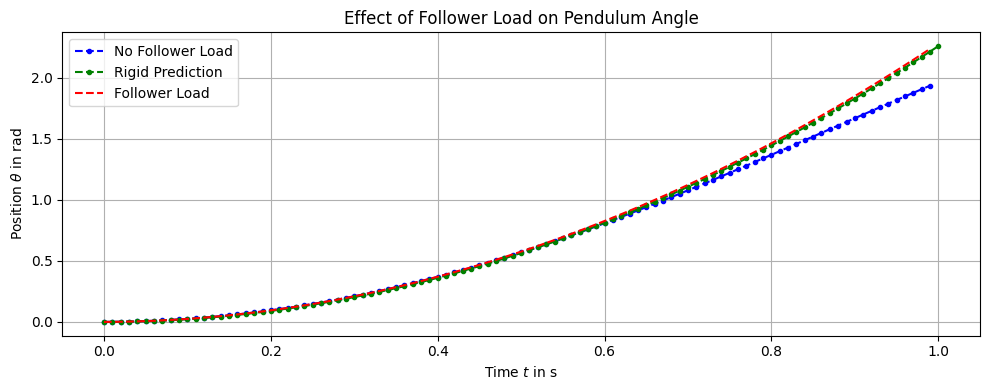

In [17]:
t_vals = np.array(res_1['t_vals'])
theta_vals_1 = np.array(res_1['theta_vals'])
theta_vals_2 = np.array(res_2['theta_vals'])

plt.figure(figsize=(10,4))
plt.title("Effect of Follower Load on Pendulum Angle")
plt.plot(t_vals, theta_vals_2, 'b.--', label='No Follower Load')
plt.plot(t_ref, theta_ref_1, 'g.--', label='Rigid Prediction')
plt.plot(t_vals, theta_vals_1, 'r--', label='Follower Load')
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Position $\theta$ in rad")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

We can identify that the effect of the follower load increases as the angle increases. As the pendulum reaches $\theta = 90 \degree$, the difference becomes more pronounced. In this position, the case `No Follower Load` applies a traction that is tangential to the hinge edge, producing no torque at all. The `Follower Load` case, however, continues to apply the full torque as desired.

## Constant Torque with Gravity

Now we repeat the same experiment with gravity enabled.

Qualitatively:
- the applied torque still injects energy (no damping here), so the pendulum continues to move
- gravity introduces an additional restoring moment that depends on angle

In [18]:
theta0 = 0
omega0 = 0

res_3 = run_simulation(dt=dt, t_end=t_end, Mz=Mz_const,
                       theta0=theta0, omega0=omega0,
                       use_gravity=True, use_follower_load=True)

res_ref_3 = solve_rigid_pendulum(t_span=(0.0, t_end),
                                 y0=(theta0, omega0),
                                 dt=dt,
                                 use_gravity=True)

In [19]:
animate_stress(res_3['vm_history'], res_3['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

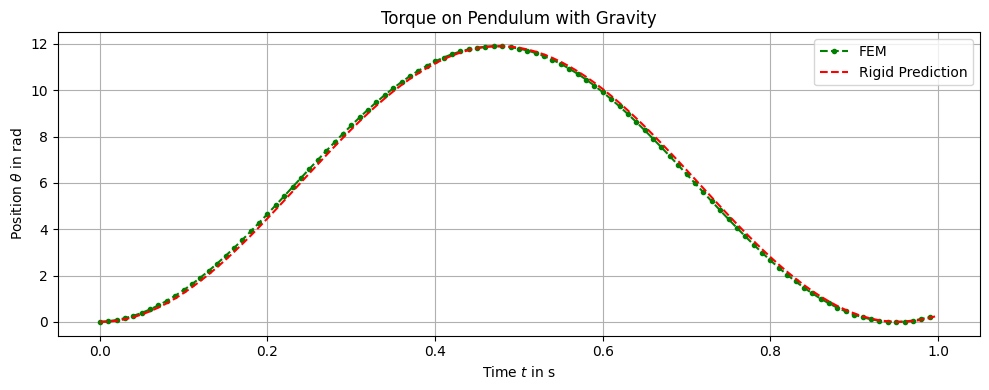

In [20]:
t_vals = np.array(res_3['t_vals'])
theta_vals_3 = np.array(res_3['theta_vals'])
t_ref, theta_ref_3, omega_ref_3 = res_ref_3
plt.figure(figsize=(10,4))
plt.title("Torque on Pendulum with Gravity")
plt.plot(t_vals, np.rad2deg(theta_vals_3), 'g.--', label='FEM')
plt.plot(t_ref, np.rad2deg(theta_ref_3), 'r--', label='Rigid Prediction')
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Position $\theta$ in rad")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

We can see that the FEM simulation with follower load closely follows the rigid-body prediction.

------------------------

## Summary

- A desired torque can be represented by a **zero-resultant traction distribution** on the hinge edge.
- The mapping torque $\rightarrow$ traction uses a precomputed effectiveness factor $D_{\mathrm{eff}}$.
- To keep the traction normal to the hinge edge during large rotations, implement it as a **follower load** using the surface transformation $nJ_s=\operatorname{cof}(F)N$.

Next: add wall contact and investigate how torque + contact interact (Tutorial 03).